In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [71]:
spy = pd.read_csv(
    "../data/raw/spy_daily.csv",
    parse_dates=["Date"],
    index_col="Date"
)

spy.head()

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2010-01-04,84.578484,113.330002,113.389999,111.510002,112.370003,118944600
2010-01-05,84.802368,113.629997,113.680000,112.849998,113.260002,111579900
2010-01-06,84.862068,113.709999,113.989998,113.430000,113.519997,116074400
2010-01-07,85.220306,114.190002,114.330002,113.180000,113.500000,131091100
2010-01-08,85.503891,114.570000,114.620003,113.660004,113.889999,126402800


In [72]:
spy.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 4197 entries, 2010-01-04 to 2026-09-10
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Adj Close  4197 non-null   float64
 1   Close      4197 non-null   float64
 2   High       4197 non-null   float64
 3   Low        4197 non-null   float64
 4   Open       4197 non-null   float64
 5   Volume     4197 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 229.5 KB


In [73]:
spy.index

DatetimeIndex(['2010-01-04', '2010-01-05', '2010-01-06', '2010-01-07',
               '2010-01-08', '2010-01-11', '2010-01-12', '2010-01-13',
               '2010-01-14', '2010-01-15',
               ...
               '2026-08-27', '2026-08-28', '2026-08-31', '2026-09-01',
               '2026-09-02', '2026-09-03', '2026-09-04', '2026-09-08',
               '2026-09-09', '2026-09-10'],
              dtype='datetime64[us]', name='Date', length=4197, freq=None)

Text(0, 0.5, 'Price')

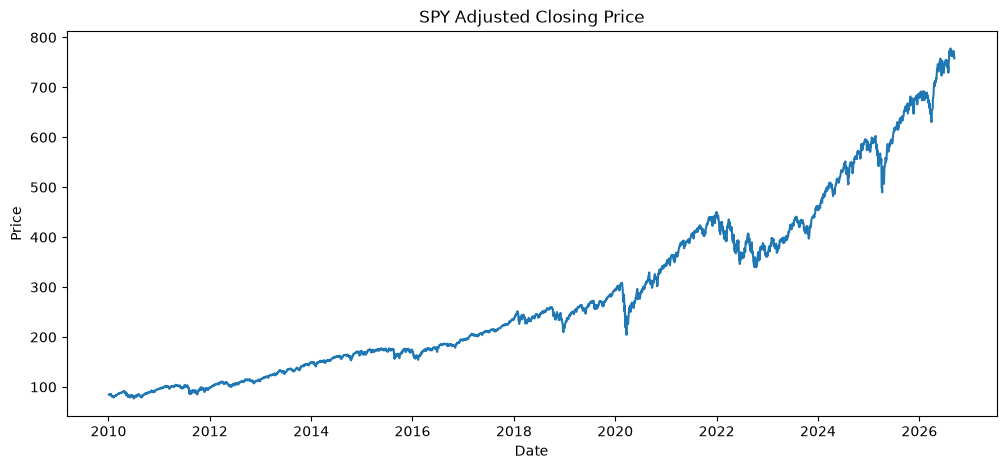

In [74]:
plt.figure(figsize=(12,5))

plt.plot(spy.index, spy["Adj Close"])
plt.title("SPY Adjusted Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")

In [75]:
weekly = spy["Adj Close"].resample("W").last()
weekly.head()

Date
2010-01-10    85.503891
2010-01-17    84.809830
2010-01-24    81.503723
2010-01-31    80.145416
2010-02-07    79.600655
Freq: W-SUN, Name: Adj Close, dtype: float64

In [76]:
monthly = spy["Adj Close"].resample("ME").last()
monthly.head()

Date
2010-01-31    80.145416
2010-02-28    82.645538
2010-03-31    87.676979
2010-04-30    89.033325
2010-05-31    81.959244
Freq: ME, Name: Adj Close, dtype: float64

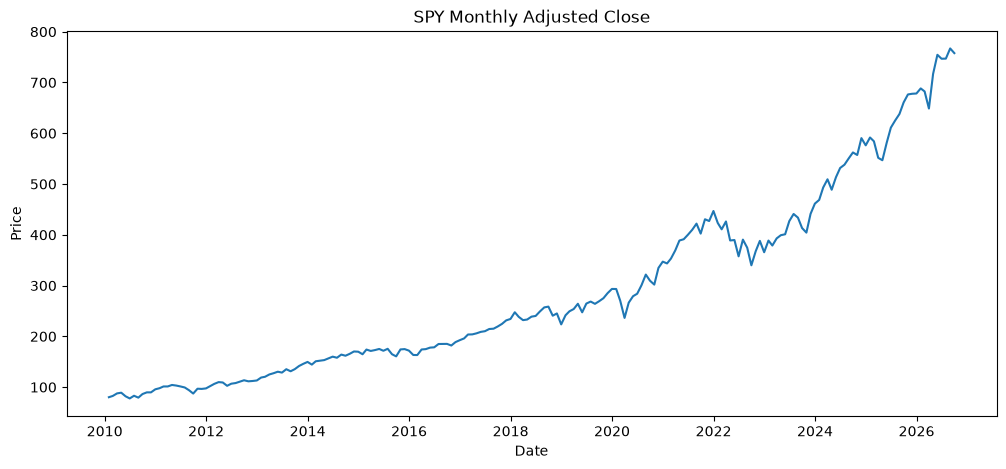

In [77]:
plt.figure(figsize = (12,5))
plt.plot(monthly.index, monthly)
plt.title("SPY Monthly Adjusted Close")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

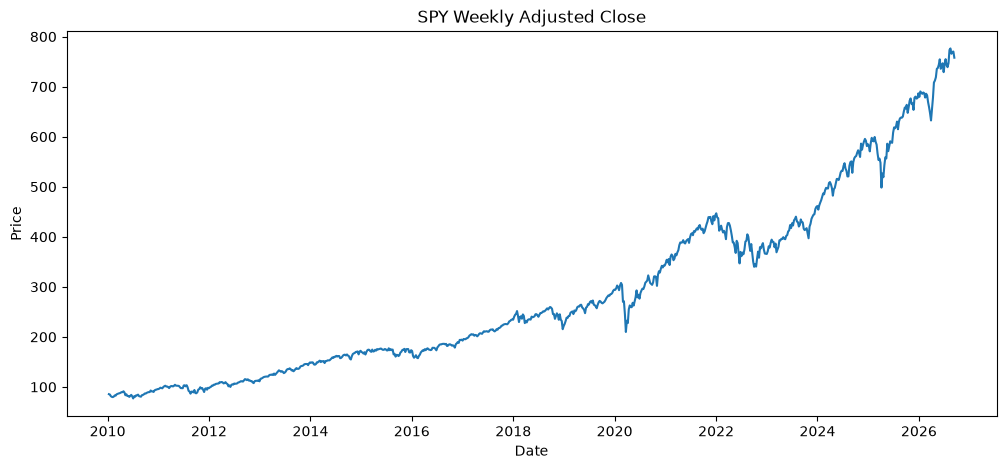

In [78]:
plt.figure(figsize = (12,5))
plt.plot(weekly.index, weekly)
plt.title("SPY Weekly Adjusted Close")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

In [79]:
spy["Simple_Return"] = spy["Adj Close"].pct_change()
spy[["Adj Close","Simple_Return"]].head()

,Adj Close,Simple_Return
Date,,
2010-01-04,84.578484,NaN
2010-01-05,84.802368,0.002647
2010-01-06,84.862068,0.000704
2010-01-07,85.220306,0.004221
2010-01-08,85.503891,0.003328


In [80]:
#Log return
spy["Log_Return"] = np.log(spy["Adj Close"]/spy["Adj Close"].shift(1))

In [81]:
spy[["Simple_Return", "Log_Return"]].head()

,Simple_Return,Log_Return
Date,,
2010-01-04,NaN,NaN
2010-01-05,0.002647,0.002644
2010-01-06,0.000704,0.000704
2010-01-07,0.004221,0.004213
2010-01-08,0.003328,0.003322


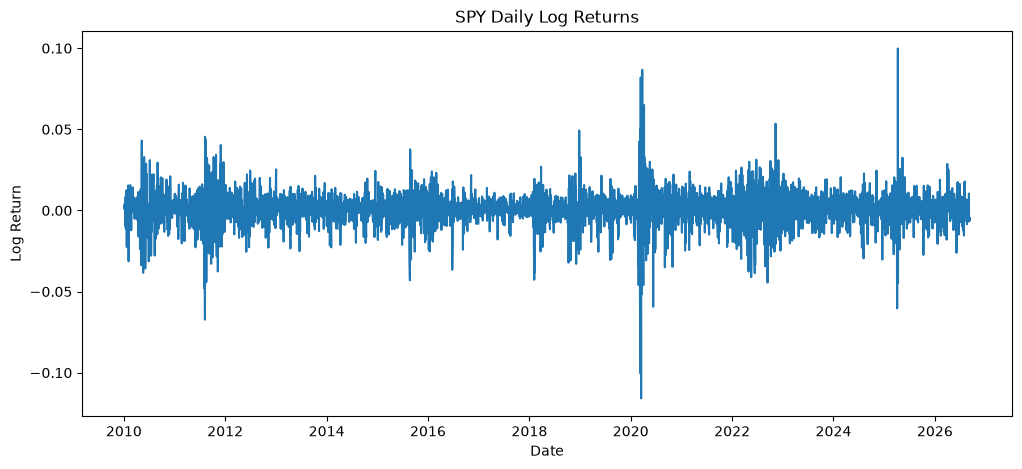

In [82]:
plt.figure(figsize=(12, 5))

plt.plot(spy.index, spy["Log_Return"])

plt.title("SPY Daily Log Returns")
plt.xlabel("Date")
plt.ylabel("Log Return")

plt.show()

In [83]:
spy["Log_Return"].describe()

count    4196.000000
mean        0.000523
std         0.010772
min        -0.115887
25%        -0.003715
50%         0.000701
75%         0.005774
max         0.099863
Name: Log_Return, dtype: float64

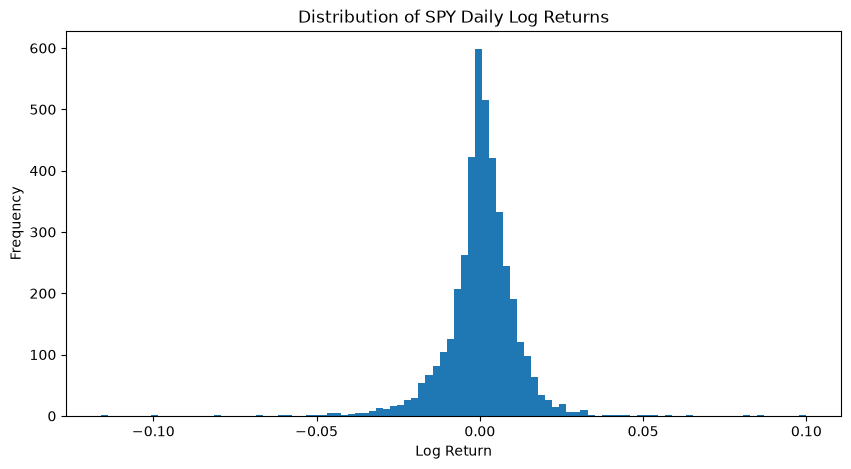

In [84]:
plt.figure(figsize=(10, 5))

plt.hist(
    spy["Log_Return"],
    bins=100
)

plt.title("Distribution of SPY Daily Log Returns")
plt.xlabel("Log Return")
plt.ylabel("Frequency")

plt.show()

In [85]:
#Rolling mean
spy["Rolling_Mean_20"] = (
    spy["Log_Return"].rolling(window=20).mean()
)

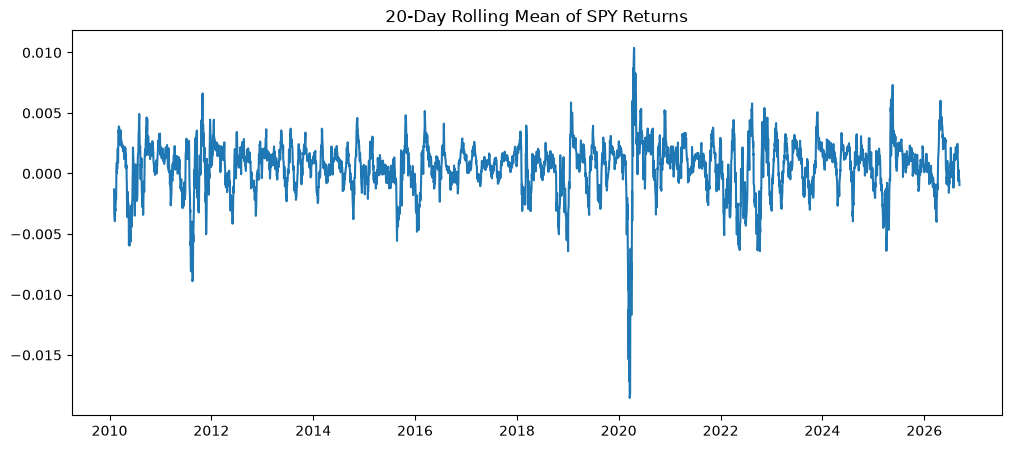

In [86]:
plt.figure(figsize=(12, 5))

plt.plot(
    spy.index,
    spy["Rolling_Mean_20"]
)

plt.title("20-Day Rolling Mean of SPY Returns")

plt.show()

In [87]:
spy["Rolling_Volatility_20"] = (
    spy["Log_Return"]
    .rolling(window=20)
    .std()
)

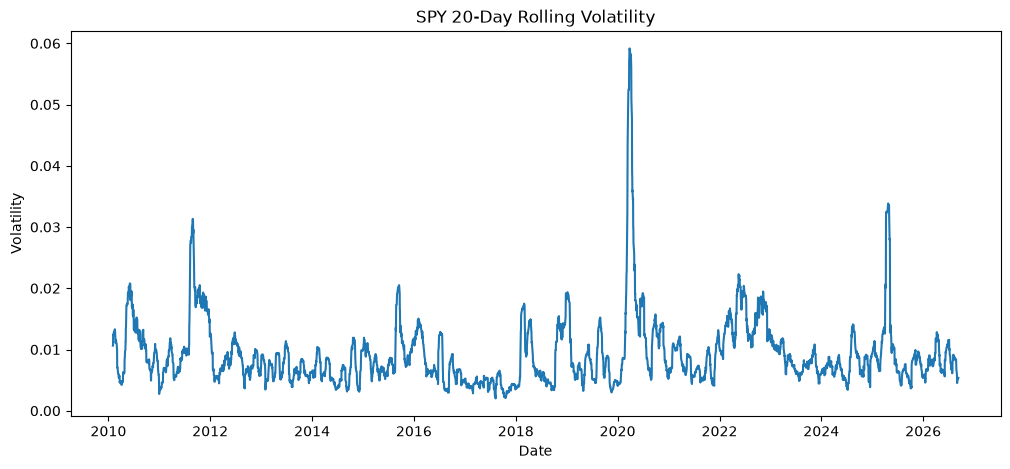

In [88]:
plt.figure(figsize=(12, 5))

plt.plot(
    spy.index,
    spy["Rolling_Volatility_20"]
)

plt.title("SPY 20-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")

plt.show()

In [89]:
#Annualized volatility
annualized_volatility = (
    spy["Log_Return"].std()
    * np.sqrt(252)
)

annualized_volatility

np.float64(0.17100088721429593)

In [90]:
spy.nsmallest(
    10,
    "Log_Return"
)[["Adj Close", "Log_Return"]]

,Adj Close,Log_Return
Date,,
2020-03-16,218.627899,-0.115887
2020-03-12,226.157059,-0.100569
2020-03-09,249.965973,-0.081313
2011-08-08,86.221085,-0.067340
2025-04-04,498.269714,-0.060326
2020-06-11,275.623047,-0.059378
2020-03-18,218.764648,-0.051960
2025-04-03,529.253723,-0.050537
2020-03-11,250.084473,-0.049977


In [91]:
spy.nlargest(
    10,
    "Log_Return"
)[["Adj Close", "Log_Return"]]

,Adj Close,Log_Return
Date,,
2025-04-09,541.008423,0.099863
2020-03-24,222.939194,0.086731
2020-03-13,245.490448,0.082028
2020-04-06,242.844620,0.065007
2020-03-26,239.488892,0.056749
2022-11-10,375.671143,0.053497
2020-03-17,230.432083,0.052585
2020-03-10,262.900543,0.050451
2018-12-26,220.227661,0.049290


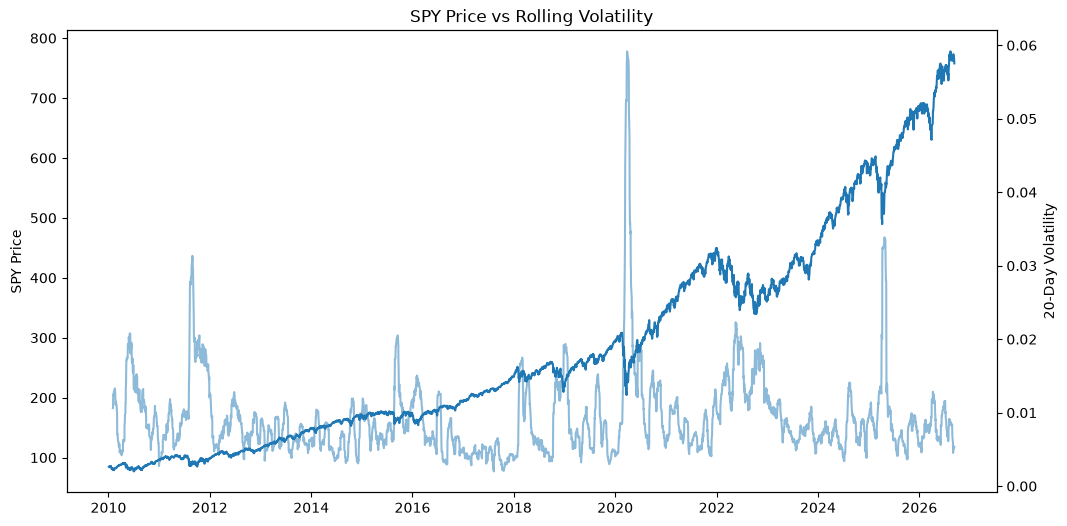

In [92]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(
    spy.index,
    spy["Adj Close"]
)

ax1.set_ylabel("SPY Price")

ax2 = ax1.twinx()

ax2.plot(
    spy.index,
    spy["Rolling_Volatility_20"],
    alpha=0.5
)

ax2.set_ylabel("20-Day Volatility")

plt.title("SPY Price vs Rolling Volatility")

plt.show()

In [93]:
mean_return = spy["Log_Return"].mean()

daily_volatility = spy["Log_Return"].std()

annual_return = mean_return * 252

annual_volatility = daily_volatility * np.sqrt(252)

print("Mean Daily Return:", mean_return)
print("Daily Volatility:", daily_volatility)
print("Annualized Return:", annual_return)
print("Annualized Volatility:", annual_volatility)

Mean Daily Return: 0.0005225879898848233
Daily Volatility: 0.010772043370010276
Annualized Return: 0.13169217345097547
Annualized Volatility: 0.17100088721429593


In [94]:
spy.to_csv(
    "../data/processed/spy_returns.csv"
)